###  MicroGrad demo

This is the vector-based version, using the `micrograd.optim.SGD` class as optimiser.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP
from micrograd.optim import SGD

In [3]:
np.random.seed(1337)
random.seed(1337)

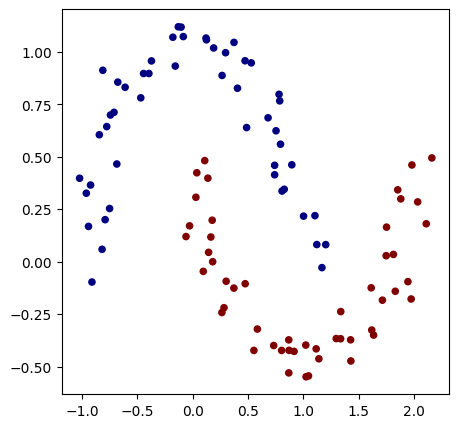

In [4]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [5]:
# the model
import numpy.random
from numpy import zeros

batch_size = 100
nn_x = Value(shape=(batch_size, 2), name='x')
nn_y = Value(shape=(batch_size,), name='y')

m1 = Value(numpy.random.uniform(-1, 1, (2, 16)))
b1 = Value(zeros(16))
m2 = Value(numpy.random.uniform(-1, 1, (16, 16)))
b2 = Value(zeros(16))
m3 = Value(numpy.random.uniform(-1, 1, (16,)))
b3 = Value(0)

def model(x):
    # (batch_size, 16)
    res1 = (x @ m1 + b1).relu()
    # (batch_size, 16)
    res2 = (res1 @ m2 + b2).relu()
    # (batch_size,)
    return res2 @ m3 + b3

y_pred = model(nn_x)

# SVM "max-margin" loss
loss = (1 - nn_y * y_pred).relu().mean()

# L2 regularisation
alpha = 1e-4
reg_loss = alpha * ((m1 ** 2).sum() + (b1 ** 2).sum()
                    + (m2 ** 2).sum() + (b2 ** 2).sum()
                    + (m3 ** 2).sum() + (b3 ** 2).sum())

# quantity to minimise
total_loss = loss + reg_loss

In [6]:
total_loss.forward(x=X, y=y)
print(total_loss)

Value(data=1.5810633866346033, grad=None)


In [8]:
# optimization
def learning_rate_schedule(start, decrement):
    assert start >= 0
    assert decrement >= 0
    
    r = start
    while r >= 0:
        yield r
        r -= decrement
        
optimiser = SGD(wrt=[m1, b1, m2, b2, m3, b3],
                learning_rate=learning_rate_schedule(
                    start=1, decrement=.9 / 100))


#print((m1.data ** 2).sum() + (b1.data ** 2).sum())
#print((m2.data ** 2).sum() + (b2.data ** 2).sum())
#print((m3.data ** 2).sum() + b3.data ** 2)

for k in range(100):
    total_loss.forward(x=X, y=y)
    total_loss.backward()
    optimiser.step()
    acc = ((y_pred.data > 0) == (nn_y.data > 0)).astype(int).mean()
    print(f"step {k} loss {total_loss.data:.6f}, accuracy {acc*100}%")

    #print((m1.data ** 2).sum() + (b1.data ** 2).sum(),
    #      (m1.grad ** 2).sum() + (b1.grad ** 2).sum())
    #print((m2.data ** 2).sum() + (b2.data ** 2).sum(),
    #      (m2.grad ** 2).sum() + (b2.grad ** 2).sum())
    #print((m3.data ** 2).sum() + (b3.data ** 2),
    #      (m3.grad ** 2).sum() + (b3.grad ** 2))


step 0 loss 1.581063, accuracy 48.0%
step 1 loss 1.384858, accuracy 68.0%
step 2 loss 0.934716, accuracy 74.0%
step 3 loss 0.727044, accuracy 78.0%
step 4 loss 0.384791, accuracy 84.0%
step 5 loss 0.348114, accuracy 85.0%
step 6 loss 0.269266, accuracy 88.0%
step 7 loss 0.223788, accuracy 91.0%
step 8 loss 0.183176, accuracy 92.0%
step 9 loss 0.183144, accuracy 94.0%
step 10 loss 0.234310, accuracy 91.0%
step 11 loss 0.250955, accuracy 90.0%
step 12 loss 0.189704, accuracy 93.0%
step 13 loss 0.139192, accuracy 95.0%
step 14 loss 0.141982, accuracy 94.0%
step 15 loss 0.159697, accuracy 98.0%
step 16 loss 0.447638, accuracy 84.0%
step 17 loss 0.196442, accuracy 92.0%
step 18 loss 0.124547, accuracy 96.0%
step 19 loss 0.139352, accuracy 92.0%
step 20 loss 0.108038, accuracy 99.0%
step 21 loss 0.139528, accuracy 95.0%
step 22 loss 0.077637, accuracy 97.0%
step 23 loss 0.074556, accuracy 98.0%
step 24 loss 0.054618, accuracy 98.0%
step 25 loss 0.059493, accuracy 100.0%
step 26 loss 0.095297

(-1.548639298268643, 1.951360701731357)

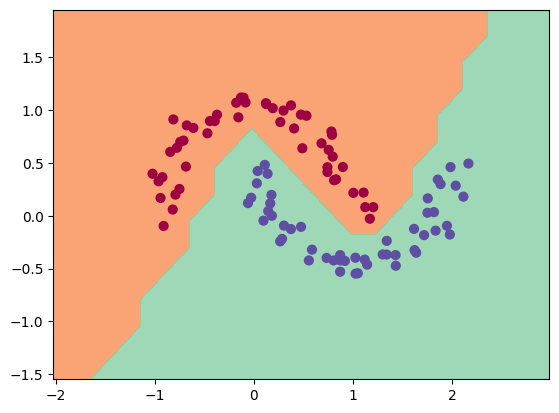

In [9]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
#inputs = [list(map(Value, xrow)) for xrow in Xmesh]
#scores = list(map(model, inputs))
scores = model(Value(Xmesh)) 
Z = scores.data > 0
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
